# Практика 2 — Исследование данных (EDA)

**Модуль 02 · AI HUB**

---

## Что делаем в этой практике

Берём чистый датасет из Практики 1 и исследуем его:
1. Смотрим на распределения и баланс классов
2. Считаем статистики: mean, median, IQR
3. Вычисляем мета-признаки и строим графики
4. Проверяем гипотезу статистическим тестом

**Главный вопрос практики:** чем SMS-спам отличается от обычного сообщения?

---

**Сдача:** Pull Request с этим ноутбуком. Должны быть:
- Минимум 4 графика
- Результат Mann–Whitney с выводом
- Текстовый вывод в конце: какие три признака нашли

## Настройка окружения

Запустите ячейку ниже.

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Всё импортировано успешно.")

Всё импортировано успешно.


---

## Задание 1 — Загрузка данных из Практики 1

Загрузите датасет, который подготовили в Практике 1. Если запускаете впервые — нужно повторить шаги загрузки и чистки из ноутбука `01_preprocess.ipynb`.

**Что нужно сделать:**
1. Загрузите `data`, создайте `is_spam` и `len`, уберите пустые строки
2. Добавьте мета-признаки (они нужны для заданий ниже):
   - `caps_ratio` — доля заглавных букв в тексте
   - `exclaim_ratio` — доля `!` в тексте
   - `digit_ratio` — доля цифр в тексте
3. Выведите `df.shape` и `df.columns`

> Формула для долей: `df['text'].str.count(r'[A-Z]') / df['len'].clip(lower=1)`. Аналогично для `!` и `Цифры`.

In [3]:
import csv
df_2 = pd.read_csv('pre_data.csv')
print(df_2.head())
df_2['len'] = df_2['text'].str.len()
df_2['caps_ratio'] = df_2['text'].str.count(r'[A-Z]') / df_2['len'].clip(lower=1)
df_2['exclaim_ratio'] = df_2['text'].str.count(r'!') / df_2['len'].clip(lower=1)
df_2['digit_ratio'] = df_2['text'].str.count(r'\d') / df_2['len'].clip(lower=1)
print(df_2.shape)
print(df_2.columns)
#df_2.drop('len', axis=1, inplace=True)


  label                                               text  is_spam  len  \
0   ham  Go until jurong point, crazy.. Available only ...        0  111   
1   ham                      Ok lar... Joking wif u oni...        0   29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        1  155   
3   ham  U dun say so early hor... U c already then say...        0   49   
4   ham  Nah I don't think he goes to usf, he lives aro...        0   61   

                                          clean_text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  
(5572, 8)
Index(['label', 'text', 'is_spam', 'len', 'clean_text', 'caps_ratio',
       'exclaim_ratio', 'digit_ratio'],
      dtype='object')


---

## Задание 2 — Баланс классов

Первое, что смотрят в любой задаче классификации — как распределены классы. Если один класс встречается сильно реже — это повлияет на выбор метрик и обучение модели.

**Что нужно сделать:**
1. Посчитайте количество и долю ham и spam
2. Постройте bar chart: ось X — класс (ham/spam), ось Y — количество
3. Подпишите каждый столбец: сколько примеров и какой процент

> Используйте `df['is_spam'].value_counts()` и метод `.plot.bar()` или `sns.countplot()`.

Количество:
label
ham     4825
spam     747
Name: count, dtype: int64

Доля:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


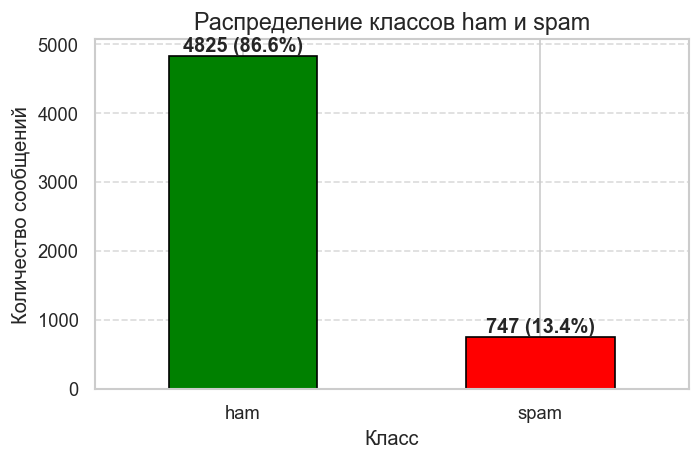

In [4]:
counts = df_2['label'].value_counts()
print("Количество:")
print(counts)
ratios = df_2['label'].value_counts(normalize=True)*100
print("\nДоля:")
print(ratios)

total = counts.sum()

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['green', 'red'], edgecolor='black')

plt.title('Распределение классов ham и spam', fontsize=14)
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество сообщений', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(counts):
    percentage = 100 * v / total
    label = f'{v} ({percentage:.1f}%)'   
    plt.text(i, v + 5, label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Вывод:**  
*(напишите здесь)*
слова "ham" встречаются чаще, чем "spam", можно проанализировать список слов, и возможно добавить часть в стоп лист

---

## Задание 3 — Статистики длин по классам

Длина сообщения — один из первых признаков, который стоит проверить. Посмотрим на статистику отдельно для ham и spam.

**Что нужно сделать:**
1. Сгруппируйте по `is_spam` и посчитайте `mean`, `median`, `std`, `min`, `max` для `len`
2. Выведите результат
3. Сравните: насколько отличаются медианы? В сколько раз?

>`df.groupby('is_spam')['len'].describe()` — выводит все статистики сразу.



In [42]:
stats = df_2.groupby('is_spam')['len'].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats)
df_2.groupby('is_spam')['len'].describe()

               mean  median        std  min  max
is_spam                                         
0         71.023627    52.0  58.016023    2  910
1        138.866131   149.0  29.183082   13  224


,count,mean,std,min,25%,50%,75%,max
is_spam,,,,,,,,
0,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
1,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


**Вывод:**  
*(напишите здесь)* <br>
<span style="color: red;"><b>Нужно написать вывод<b></span>
медианы отличатся кардинально, примерно в  2.8 раз

---

## Задание 4 — Распределение длин (гистограмма)

Таблица с медианами — хорошо, но график показывает форму распределения целиком. Нужно посмотреть, как длины распределены отдельно для ham и spam.

**Что нужно сделать:**
1. Постройте гистограмму длин с `hue='is_spam'`
2. Используйте логарифмическую шкалу по оси X (`log_scale=True`) — так лучше виден хвост
3. Добавьте заголовок и подписи осей
4. Добавьте вертикальные линии для медиан ham и spam

> `sns.histplot(data=df, x='len', hue='is_spam', log_scale=True, bins=50)`


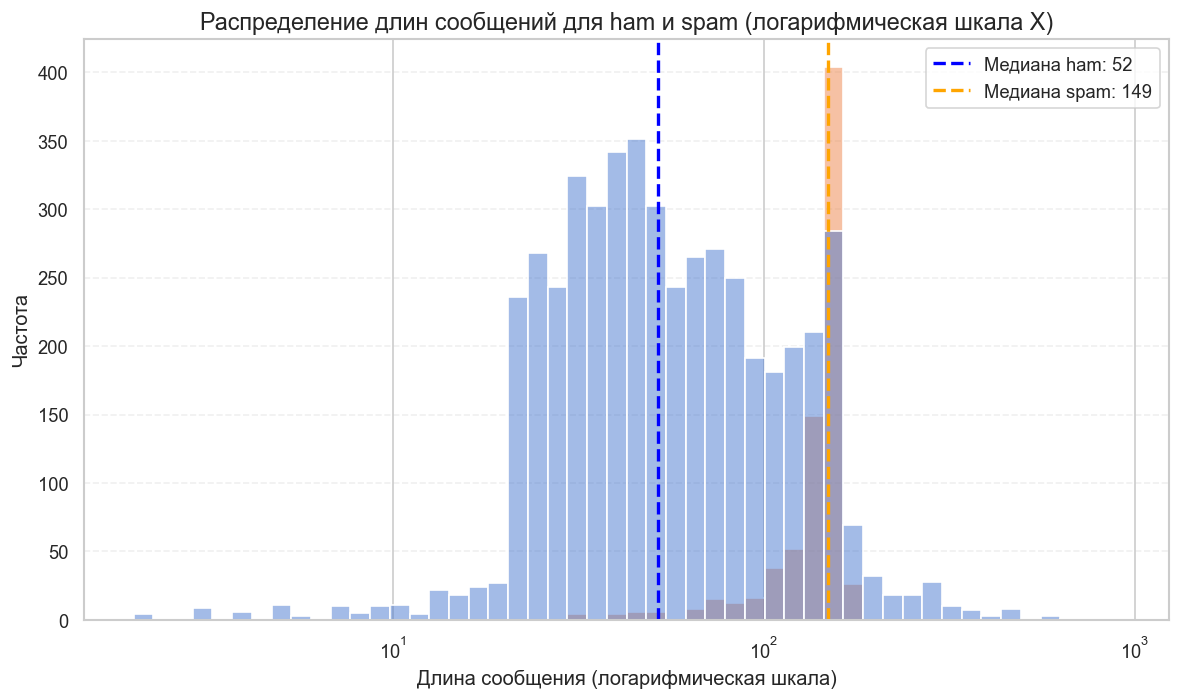

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_2, x='len', hue='is_spam_cat', log_scale=True, bins=50), #alpha=0.7)


plt.title('Распределение длин сообщений для ham и spam (логарифмическая шкала X)', fontsize=14)
plt.xlabel('Длина сообщения (логарифмическая шкала)', fontsize=12)
plt.ylabel('Частота', fontsize=12)


medians = df_2.groupby('is_spam')['len'].median()
plt.axvline(medians[0], color='blue', linestyle='--', linewidth=2, label=f'Медиана ham: {medians[0]:.0f}')
plt.axvline(medians[1], color='orange', linestyle='--', linewidth=2, label=f'Медиана spam: {medians[1]:.0f}')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**  
*(напишите здесь)* <br>
<span style="color: red;"><b>Нужно написать вывод<b></span>
частота сообщений примерно одинакова, однако длина сообщений "spam" больше относительно "ham"

---

## Задание 5 — Мета-признаки: caps_ratio и digit_ratio

Спам часто пишут КАПСОМ и набивают цифрами — коды купонов, номера, суммы скидок. Проверим это.

**Что нужно сделать:**
1. Постройте два boxplot рядом (subplots 1×2):
   - Первый: `caps_ratio` по классу `is_spam`
   - Второй: `digit_ratio` по классу `is_spam`
2. Добавьте заголовки и подпись осей
3. Посчитайте медиану каждого признака для ham и spam — выведите текстом

> `fig, axes = plt.subplots(1, 2, figsize=(10, 4))` — создаёт два графика рядом.


C:\Users\duhas\AppData\Local\Temp\ipykernel_23740\1389407493.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='class', y='caps_ratio', ax=axes[0], palette=['green', 'red'])
C:\Users\duhas\AppData\Local\Temp\ipykernel_23740\1389407493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='class', y='digit_ratio', ax=axes[1], palette=['green', 'red'])


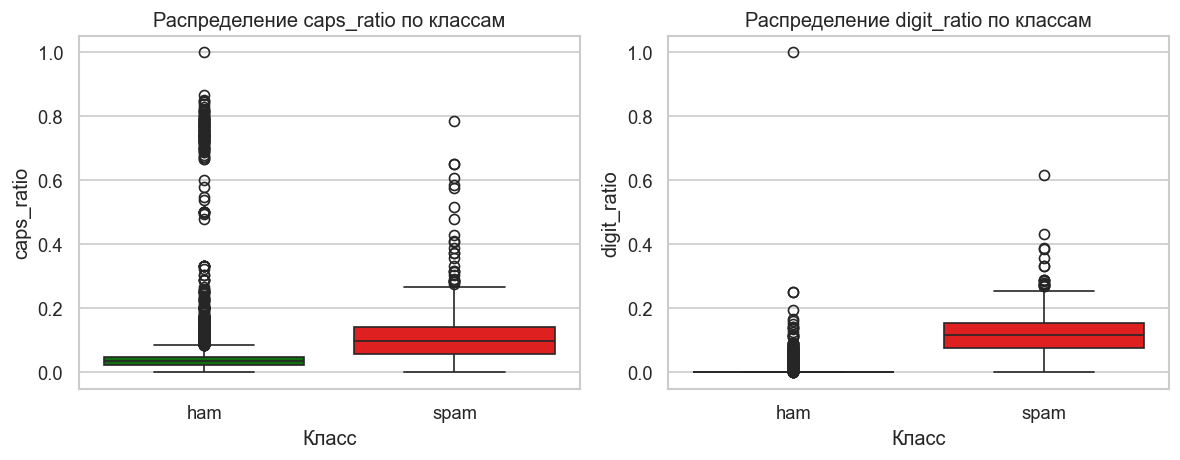

Медианы для caps_ratio:
  ham (is_spam=0): 0.0345
  spam (is_spam=1): 0.0985

Медианы для digit_ratio:
  ham (is_spam=0): 0.0000
  spam (is_spam=1): 0.1159


In [20]:
df_plot = df_2.copy()
df_plot['class'] = df_plot['is_spam'].map({0: 'ham', 1: 'spam'})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df_plot, x='class', y='caps_ratio', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Распределение caps_ratio по классам')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('caps_ratio')

sns.boxplot(data=df_plot, x='class', y='digit_ratio', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Распределение digit_ratio по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('digit_ratio')

plt.tight_layout()
plt.show()

medians_caps = df_2.groupby('is_spam')['caps_ratio'].median()
medians_digit = df_2.groupby('is_spam')['digit_ratio'].median()

print("Медианы для caps_ratio:")
print(f"  ham (is_spam=0): {medians_caps[0]:.4f}")
print(f"  spam (is_spam=1): {medians_caps[1]:.4f}")
print("\nМедианы для digit_ratio:")
print(f"  ham (is_spam=0): {medians_digit[0]:.4f}")
print(f"  spam (is_spam=1): {medians_digit[1]:.4f}")

**Вывод:**  
*(напишите здесь)* <br>
<span style="color: red;"><b>Нужно написать вывод<b></span>
сообщения типа "ham", чаще пишутся капсом, а сообщениях "spam" чаще встречаются цыфры, однако есть и исключения.

---

## Задание 6 — Топ-слова в spam и ham

Посмотрим, какие слова встречаются чаще всего в каждом классе. Это покажет лексические паттерны, которые потом поймает TF-IDF.

**Что нужно сделать:**
1. Для spam-сообщений: разбейте тексты на слова и найдите 20 самых частых
2. Сделайте то же для ham
3. Постройте два горизонтальных bar chart (subplots 1×2) — топ-15 слов для каждого класса

> 💡 Подход: `df.loc[df['is_spam']==1, 'text'].str.lower().str.findall(r"[a-z']+").explode().value_counts().head(20)`

**Какие слова характерны только для spam?** Напишите ниже.

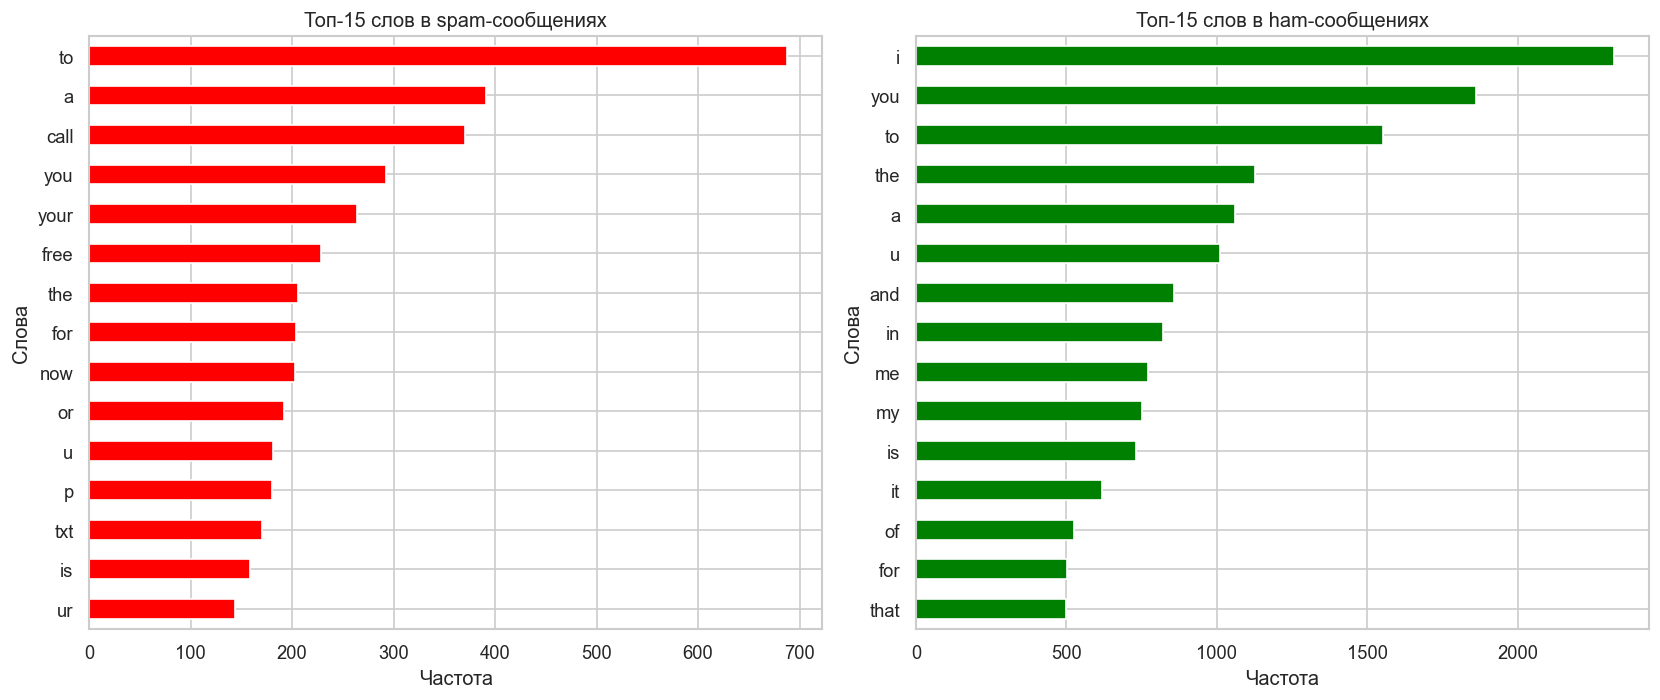

Топ-15 слов в spam:
 text
to      688
a       391
call    370
you     292
your    264
free    228
the     206
for     204
now     203
or      192
u       181
p       180
txt     170
is      158
ur      144
Name: count, dtype: int64

Топ-15 слов в ham:
 text
i       2320
you     1862
to      1554
the     1126
a       1060
u       1012
and      857
in       820
me       772
my       750
is       731
it       618
of       525
for      501
that     499
Name: count, dtype: int64


In [23]:

# Топ-20 слов для spam
spam_words = (df_2.loc[df_2['is_spam'] == 1, 'text']
              .str.lower()
              .str.findall(r"[a-z']+")   
              .explode()
              .value_counts()
              .head(15))

# Топ-20 слов для ham
ham_words = (df_2.loc[df_2['is_spam'] == 0, 'text']
             .str.lower()
             .str.findall(r"[a-z']+")
             .explode()
             .value_counts()
             .head(15))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# spam (левый график)
spam_words.head(15).sort_values().plot(kind='barh', ax=axes[0], color='red')
axes[0].set_title('Топ-15 слов в spam-сообщениях', fontsize=12)
axes[0].set_xlabel('Частота')
axes[0].set_ylabel('Слова')
# ham (правый график)
ham_words.head(15).sort_values().plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title('Топ-15 слов в ham-сообщениях', fontsize=12)
axes[1].set_xlabel('Частота')
axes[1].set_ylabel('Слова')

plt.tight_layout()
plt.show()

print("Топ-15 слов в spam:\n", spam_words)
print("\nТоп-15 слов в ham:\n", ham_words)

**Вывод:**  
<span style="color: red;"><b>Нужно написать вывод<b></span>
слова "call, your, free", характерны только для spam

---

## Задание 7 — Проверяем гипотезу: спам длиннее ham

Из графиков видно, что spam длиннее. Но это могла быть случайность. Статистический тест даёт ответ: это случайность или нет, и насколько большая разница.

Длины не нормально распределены (log-normal с хвостом) — поэтому используем **Mann–Whitney U**, который не предполагает нормальность.

**Что нужно сделать:**
1. Разделите длины на две выборки: ham и spam
2. Примените `mannwhitneyu` с `alternative='two-sided'`
3. Выведите p-value, медиану ham, медиану spam и разницу медиан
4. Сделайте вывод: отличаются ли длины статистически значимо? Большой ли эффект?


In [24]:
from scipy.stats import mannwhitneyu

#длины по классам
len_ham = df_2.loc[df_2['is_spam'] == 0, 'len']
len_spam = df_2.loc[df_2['is_spam'] == 1, 'len']

# Расчёт медиан
median_ham = len_ham.median()
median_spam = len_spam.median()
diff_median = median_ham - median_spam  

# U-тест 
stat, p_value = mannwhitneyu(len_ham, len_spam, alternative='two-sided')

# Вывод результатов
print(f"Медиана ham: {median_ham:.2f}")
print(f"Медиана spam: {median_spam:.2f}")
print(f"Разница медиан (ham - spam): {diff_median:.2f}")
print(f"p-value: {p_value:.6e}")

Медиана ham: 52.00
Медиана spam: 149.00
Разница медиан (ham - spam): -97.00
p-value: 7.402066e-239


**Вывод:**  
*(напишите здесь: значимо ли различие и большой ли эффект?)*
сообщения spam гораздо длиннее

---

## Задание 8 — Итоговые выводы EDA

Это самое важное задание в практике. EDA — это не просто графики, это выводы, которые вы сделали.

**Что нужно сделать:**

Заполните ячейку ниже — опишите:
1. Три признака, которые отличают spam от ham (с числами)
2. Какой из них кажется самым сильным и почему
3. Что из этого можно напрямую использовать в модели

In [25]:
# Напишите код для финальной сводной таблицы:
# для каждого признака (len, caps_ratio, digit_ratio) — медиана ham и spam
summary = df_2.groupby('is_spam')[['len', 'caps_ratio', 'digit_ratio']].median().T
summary.columns = ['ham (is_spam=0)', 'spam (is_spam=1)']
summary['разница'] = summary['spam (is_spam=1)'] - summary['ham (is_spam=0)']
summary['отношение (spam/ham)'] = summary['spam (is_spam=1)'] / summary['ham (is_spam=0)']

print("Медианные значения признаков по классам:")
print(summary)

Медианные значения признаков по классам:
             ham (is_spam=0)  spam (is_spam=1)    разница  \
len                52.000000        149.000000  97.000000   
caps_ratio          0.034483          0.098485   0.064002   
digit_ratio         0.000000          0.115854   0.115854   

             отношение (spam/ham)  
len                      2.865385  
caps_ratio               2.856061  
digit_ratio                   inf  


### Найденные сигналы

| Признак | ham (медиана) | spam (медиана) | Вывод |
|---------|--------------|----------------|-------|
| len | 52 | 149 | сообщения spam гораздо длиннее |
| caps_ratio | 0.034 | 0.098 | спам сообщения чаще в примерно 2,8 раз пишутся капсом  |
| digit_ratio | 0 | 0.11 | в спам сообщениях встречаются цыфры, в ham их нет сосвем |

**Самый сильный сигнал:** *спам сообщения длинне, чаще присутсвуют большие буквы и цифры*

**Что возьмём в модель:** *в модель нужно брать ham сообщения*

---

## Итог практики 2

Если все задания выполнены:
- Есть 4+ графика с подписями
- Посчитан Mann–Whitney с выводом
- Заполнена итоговая таблица признаков

**Следующий шаг:** Практика 3 — будем обучать модель на этих данных и проверять, работает ли она.